In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
# loading the data from csv file to a Pandas DataFrame
calories = pd.read_csv('calories_6000.csv')

In [6]:
# print the first 5 rows of the dataframe
calories.head()

,User_ID,Calories
0,58799639,321
1,77310995,556
2,14750251,434
3,29386843,330
4,38269030,401


In [7]:
exercise=pd.read_csv('exercise_6000.csv')

In [8]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,58799639,male,43,177,77,27,141,37.0
1,77310995,male,42,150,86,66,190,37.7
2,14750251,male,23,192,55,74,79,37.8
3,29386843,male,67,158,66,31,147,37.1
4,38269030,male,30,173,86,14,163,40.0


In [9]:
#Combining the two dataframes
#axis=1 means joining the data horizontally. If we would have kept axis=0, the data would have been joined vertically
calories_data = pd.concat([exercise, calories['Calories']], axis=1)

In [10]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,58799639,male,43,177,77,27,141,37.0,321
1,77310995,male,42,150,86,66,190,37.7,556
2,14750251,male,23,192,55,74,79,37.8,434
3,29386843,male,67,158,66,31,147,37.1,330
4,38269030,male,30,173,86,14,163,40.0,401


In [11]:
# checking the number of rows and columns
calories_data.shape

(6000, 9)

In [12]:
# getting some informations about the data
calories_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     6000 non-null   int64  
 1   Gender      6000 non-null   str    
 2   Age         6000 non-null   int64  
 3   Height      6000 non-null   int64  
 4   Weight      6000 non-null   int64  
 5   Duration    6000 non-null   int64  
 6   Heart_Rate  6000 non-null   int64  
 7   Body_Temp   6000 non-null   float64
 8   Calories    6000 non-null   int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 422.0 KB


In [13]:
# checking for missing values
calories_data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [14]:
# get some statistical measures about the data
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.00000,6000.000000
mean,5.449840e+07,43.722667,175.129667,77.323833,47.423500,130.716833,39.26425,440.774667
std,2.599896e+07,15.333817,14.700653,18.848992,24.862586,34.970780,1.28364,102.672920
min,1.000941e+07,18.000000,150.000000,45.000000,5.000000,70.000000,37.00000,165.000000
25%,3.191428e+07,30.000000,162.000000,61.000000,26.000000,101.000000,38.20000,363.000000
50%,5.445829e+07,44.000000,175.000000,78.000000,46.000000,131.000000,39.30000,439.000000
75%,7.685789e+07,57.000000,188.000000,93.000000,69.000000,162.000000,40.40000,516.000000
max,9.999771e+07,70.000000,200.000000,110.000000,90.000000,190.000000,41.50000,735.000000


<Axes: xlabel='count', ylabel='Gender'>

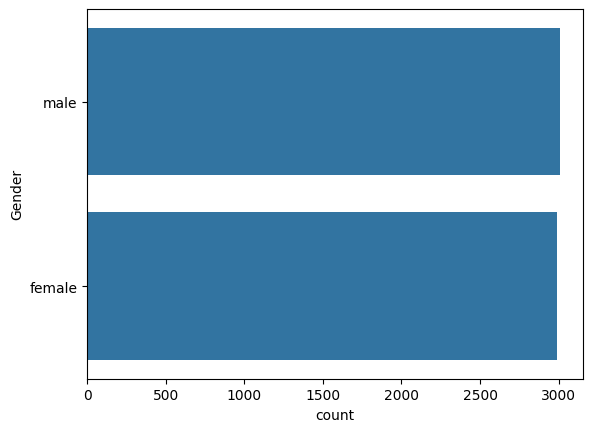

In [15]:
# plotting the gender column in count plot
sns.countplot(calories_data['Gender'])

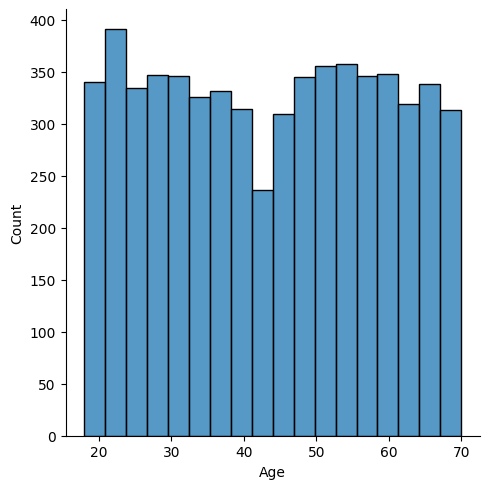

In [19]:
# finding the distribution of "Age" column
sns.displot(calories_data['Age'])

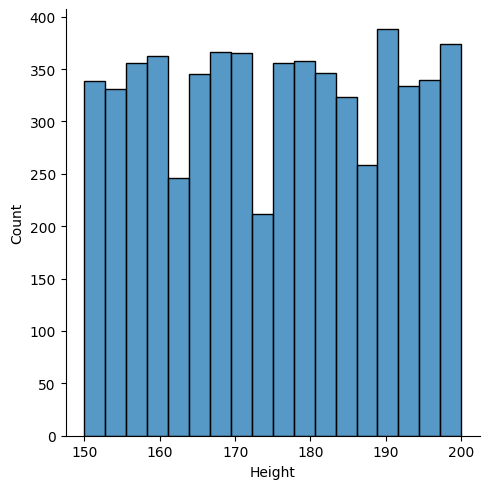

In [20]:
# finding the distribution of "Height" column
sns.displot(calories_data['Height'])

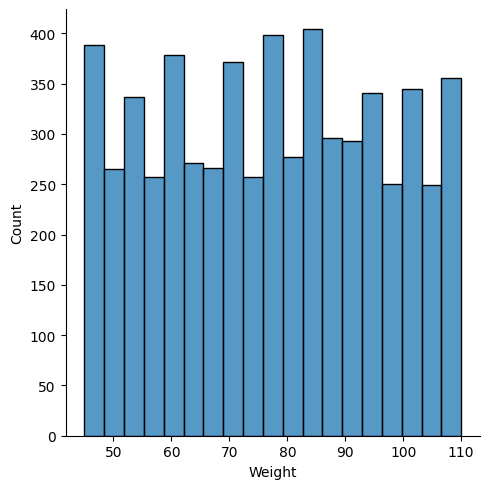

In [21]:
# finding the distribution of "Weight" column
sns.displot(calories_data['Weight'])

In [25]:
#Converting the text data to numerical values
calories_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,58799639,0,43,177,77,27,141,37.0,321
1,77310995,0,42,150,86,66,190,37.7,556
2,14750251,0,23,192,55,74,79,37.8,434
3,29386843,0,67,158,66,31,147,37.1,330
4,38269030,0,30,173,86,14,163,40.0,401
...,...,...,...,...,...,...,...,...,...
5995,89923273,1,69,187,105,12,177,39.8,422
5996,80676835,0,57,181,78,73,140,39.3,528
5997,47685784,0,50,194,64,65,110,40.3,500
5998,18749613,0,67,191,47,23,128,39.2,314


In [26]:
#finding the correlation in the dataset
correlation = calories_data.corr()

<Axes: >

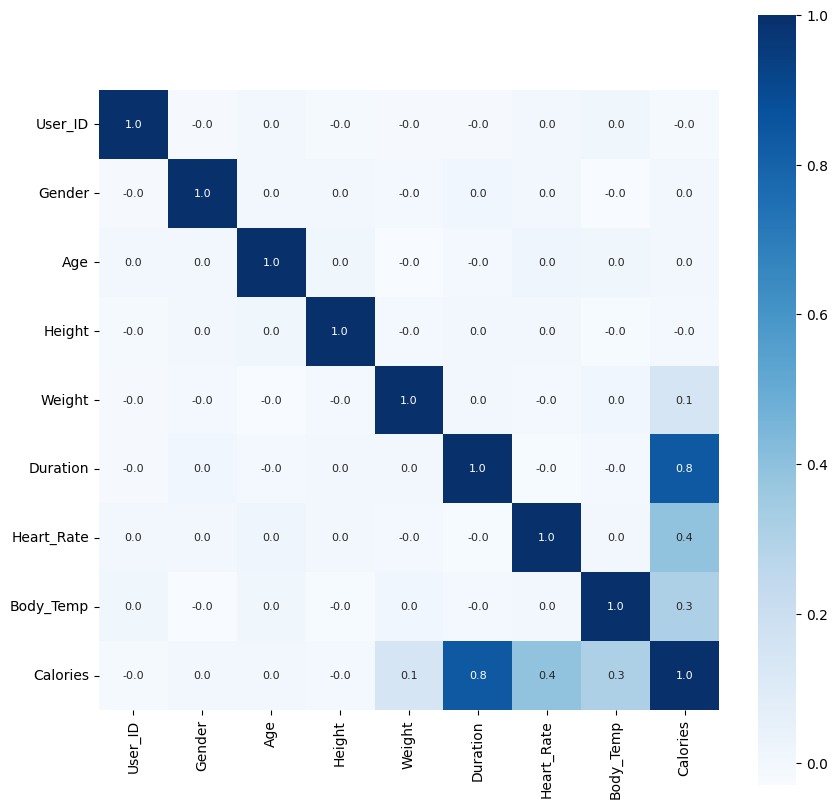

In [27]:
# constructing a heatmap to understand the correlation

plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [29]:
#Separating features and target
X = calories_data.drop(columns=['User_ID', 'Calories'])
Y = calories_data['Calories']

In [30]:
X

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,43,177,77,27,141,37.0
1,0,42,150,86,66,190,37.7
2,0,23,192,55,74,79,37.8
3,0,67,158,66,31,147,37.1
4,0,30,173,86,14,163,40.0
...,...,...,...,...,...,...,...
5995,1,69,187,105,12,177,39.8
5996,0,57,181,78,73,140,39.3
5997,0,50,194,64,65,110,40.3
5998,0,67,191,47,23,128,39.2


In [31]:
Y

0       321
1       556
2       434
3       330
4       401
       ... 
5995    422
5996    528
5997    500
5998    314
5999    462
Name: Calories, Length: 6000, dtype: int64

In [33]:
#Splitting the data into train and test data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [34]:
print(X.shape, X_train.shape, X_test.shape)

(6000, 7) (4800, 7) (1200, 7)


In [36]:
#loading the model
model = RandomForestRegressor(n_estimators=100,
    criterion='squared_error',
    random_state=42
)

In [37]:
# training the model with X_train
model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
model.predict(X_test)
#Testing with test data

array([454.77, 256.22, 446.02, ..., 190.95, 575.2 , 418.31], shape=(1200,))

In [39]:
model.score(X_test,Y_test)

0.9803138400674211

In [40]:
X.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,43,177,77,27,141,37.0
1,0,42,150,86,66,190,37.7
2,0,23,192,55,74,79,37.8
3,0,67,158,66,31,147,37.1
4,0,30,173,86,14,163,40.0


In [41]:
model.predict([[0,24,170,72,30,90,38]])

C:\Users\I528383\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([304.])